This notebook trains **Support Vector Regression (SVR)** models to predict taxi-trip demand in spatio-temporal resolution (spatial unit × time basket) using the prepared datasets in `data/2026_07_17_dataset/03`.

Three temporal resolutions are available (**1 h, 4 h, 1 d**) and two spatial layers (**census tract, community area**), each pre-split into **train / validation / test**.

### Approach (sequential model selection)
All 24 combinations (2 spatial × 3 temporal × 2 target settings × 2 encoding options) are trained once; the analysis then proceeds in four selection phases so that each decision builds on the previous one:

| Phase | Question | Configurations |
|---|---|---|
| **Full grid** | train every combination once | 2 spatial × 3 temporal × 2 target × 2 encoding |
| **Phase 1 — Spatial layer** (1 h) | census tract vs community area | both *normal* target, weather features |
| **Phase 2 — Target encoding** (1 h) | with vs without target encoding | both spatial layers |
| **Phase 3 — Target transform** (1 h) | normal vs `log1p` | best spatial layer from Phase 1 |
| **Phase 4 — Temporal resolution** | 1 h vs 4 h vs 1 d | best spatial + best target from Phase 3 |

The model family (LinearSVR → RBF → Polynomial) and all hyperparameters are selected with **grid search on the validation set** (see *Validation strategy*). Final performance is always reported on the held-out **test set**.

## 0) Setup and configuration


In [5]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = "../data/2026_07_17_dataset/03"

# colours for plots (matplotlib named colours)
SPATIAL_COLORS = {"census_tract": "steelblue", "community_area": "seagreen"}
BIN_COLORS = {"1h": "steelblue", "4h": "darkorange", "1d": "mediumpurple"}


# 1) Data loading
Each dataset comes as three pre-split parquet files (**train / val / test**). The splits were created chronologically in notebook *03* (most recent period = test, the period before = validation). All six dataset configurations (2 spatial × 3 temporal) share the same 32 columns.


In [6]:
# census_tract
ct_1h_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_train.parquet")
ct_1h_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_val.parquet")
ct_1h_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_test.parquet")
ct_4h_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_train.parquet")
ct_4h_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_val.parquet")
ct_4h_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_test.parquet")
ct_1d_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_train.parquet")
ct_1d_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_val.parquet")
ct_1d_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_test.parquet")
# community_area
ca_1h_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_train.parquet")
ca_1h_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_val.parquet")
ca_1h_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_test.parquet")
ca_4h_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_train.parquet")
ca_4h_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_val.parquet")
ca_4h_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_test.parquet")
ca_1d_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_train.parquet")
ca_1d_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_val.parquet")
ca_1d_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_test.parquet")

# quick overview of the two 1h datasets
for name, tr in [("census_tract_1h", ct_1h_train), ("community_area_1h", ca_1h_train)]:
    print(f"{name}: train={tr.shape[0]:,}  trip_count mean={tr['trip_count'].mean():.1f}")


census_tract_1h: train=6,762,388  trip_count mean=0.6
community_area_1h: train=1,100,854  trip_count mean=8.5


In [7]:
# centroids required in all datasets (delivered with the updated parquets)
for name, df in [("ct_1h_train", ct_1h_train), ("ca_1h_train", ca_1h_train)]:
    missing = [c for c in ("centroid_lat", "centroid_lon") if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing centroid columns: {missing} "
                         "-> use the updated parquet files")


## 1.2) Missing-value check & cleaning
The parquet files can contain missing values in two forms: `null` (truly missing, mostly weather-flag columns) and `NaN` (IEEE float, in the temperature columns). We inspect every dataset for **both**, then clean per-column type:

| Column type | Strategy | Reason |
|---|---|---|
| weather flags (`rain`, `strong_rain`, `snow`, `wind`, `strong_wind`) | fill with `0` | 0 = "no event", safe default |
| temperature (`temperature_c`, `temperature_max_c`, `temperature_min_c`) | fill with column mean | avoids biasing toward the freezing point |
| coordinates (`centroid_lat`, `centroid_lon`) | **drop row** | geographic location cannot be 0-imputed |

## 1.1) Target distribution
`trip_count` is right-skewed with a long tail — typical for demand data. Most spatial-unit/time baskets have low counts while a few have very high demand. This skew motivates the `log1p` target transform tested in Phase 2.


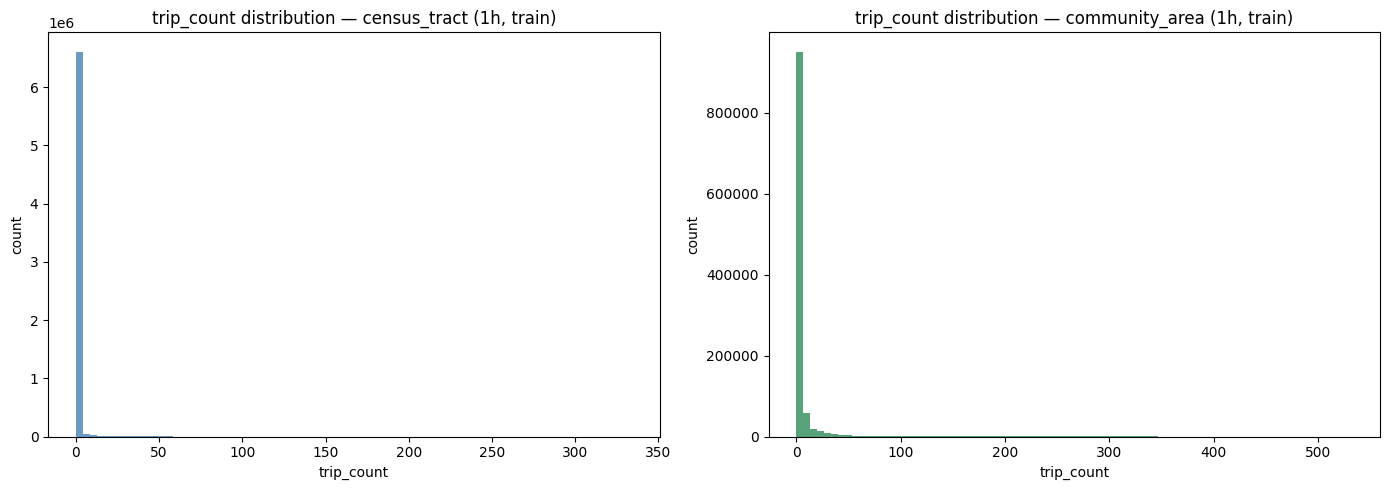

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (spatial, tr) in zip(axes, [("census_tract", ct_1h_train), ("community_area", ca_1h_train)]):
    ax.hist(tr["trip_count"].to_numpy(), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    ax.set_title(f"trip_count distribution — {spatial} (1h, train)")
    ax.set_xlabel("trip_count"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()


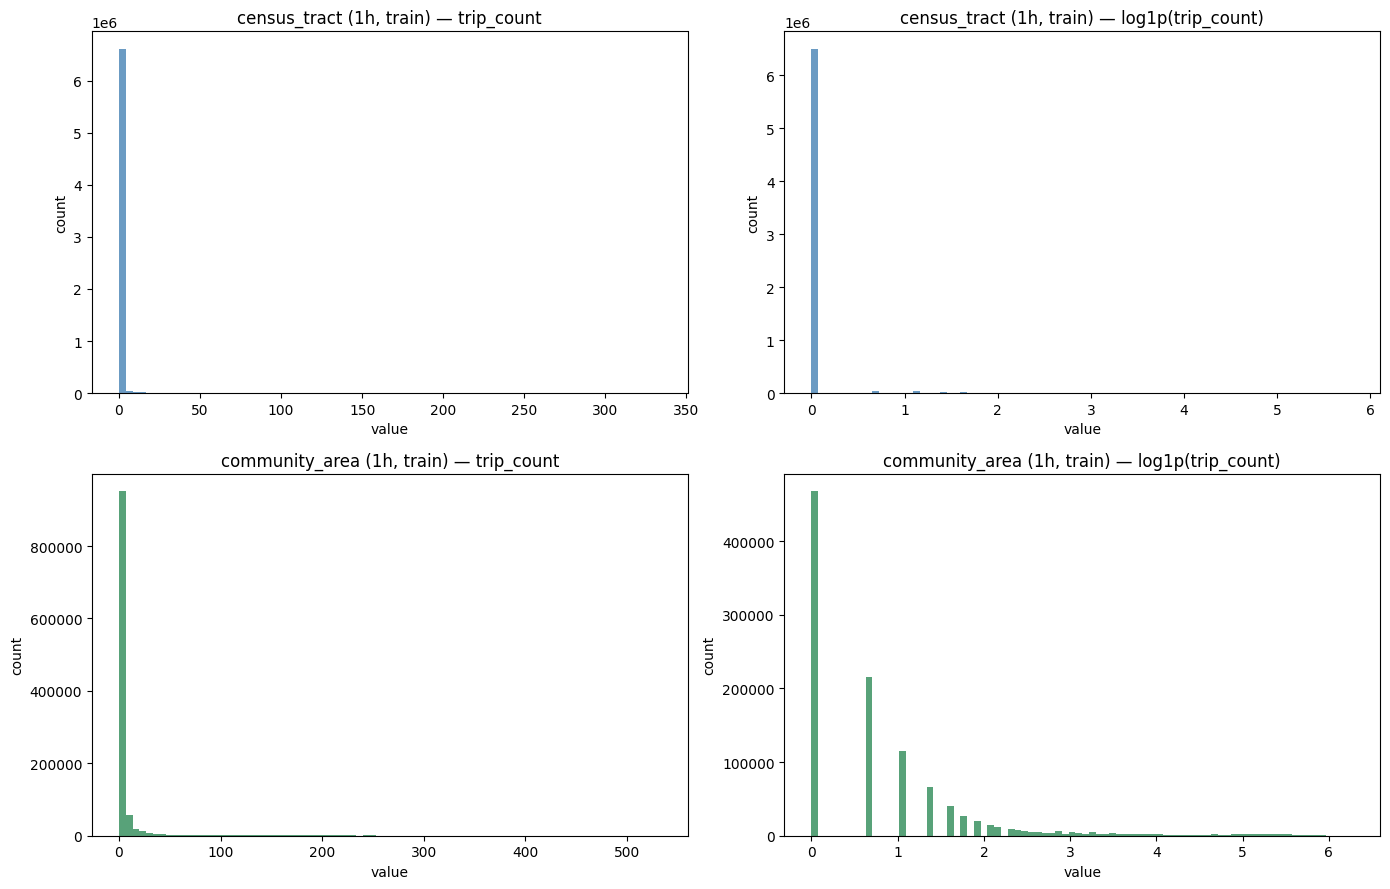

In [9]:
# right-skewed target -> motivates the log1p transform tested in Phase 2
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (spatial, tr) in enumerate([("census_tract", ct_1h_train),
                                     ("community_area", ca_1h_train)]):
    vals = tr["trip_count"].to_numpy()
    axes[row, 0].hist(vals, bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 0].set_title(f"{spatial} (1h, train) — trip_count")
    axes[row, 1].hist(np.log1p(vals), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 1].set_title(f"{spatial} (1h, train) — log1p(trip_count)")
    for ax in axes[row]:
        ax.set_xlabel("value"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

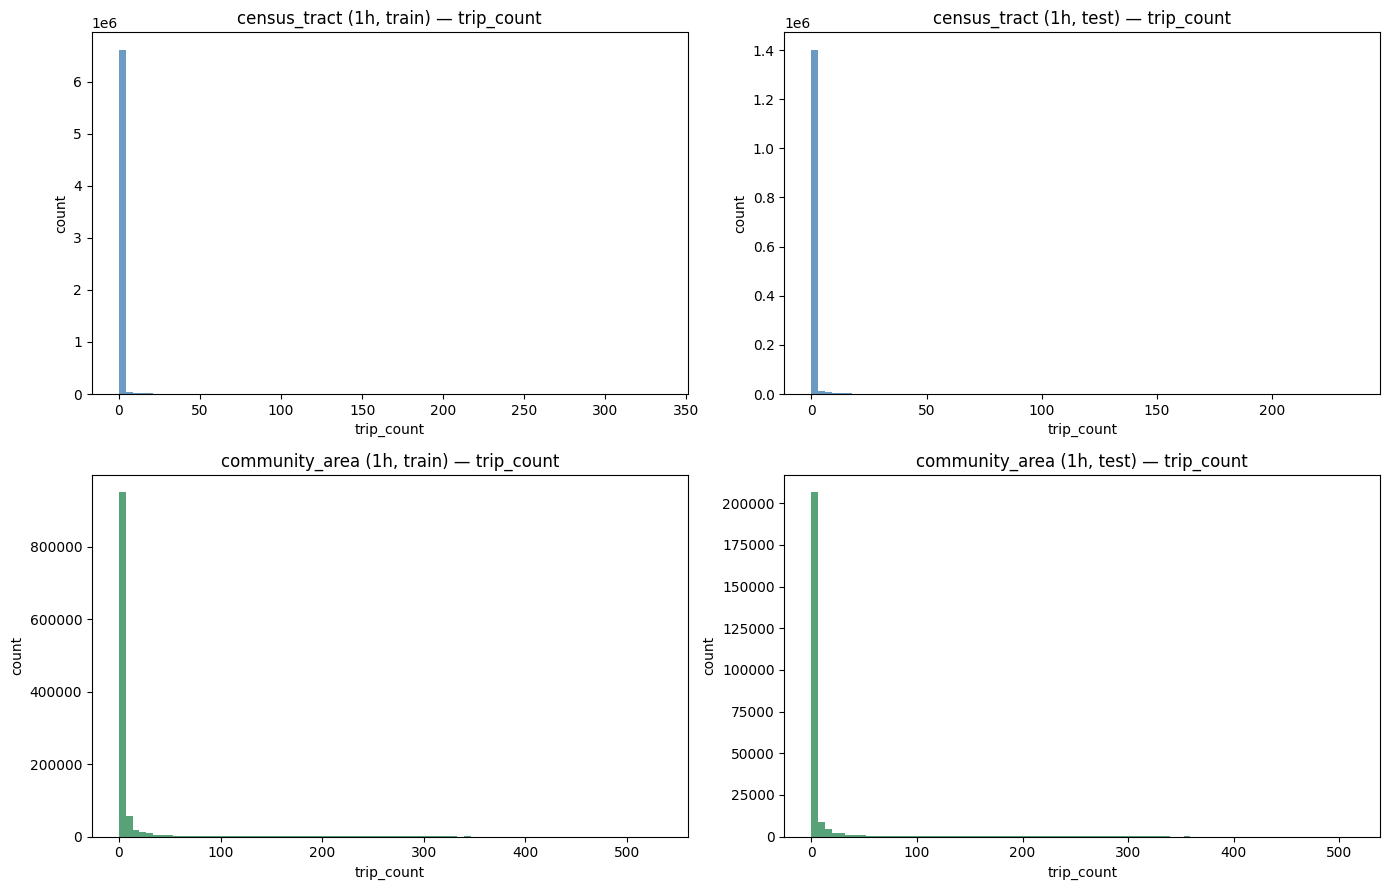

In [10]:
# check: is the test distribution representative of training?
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (spatial, tr, te) in enumerate([("census_tract", ct_1h_train, ct_1h_test),
                                         ("community_area", ca_1h_train, ca_1h_test)]):
    axes[row, 0].hist(tr["trip_count"].to_numpy(), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 0].set_title(f"{spatial} (1h, train) — trip_count")
    axes[row, 1].hist(te["trip_count"].to_numpy(), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 1].set_title(f"{spatial} (1h, test) — trip_count")
    for ax in axes[row]:
        ax.set_xlabel("trip_count"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()


# 2) Feature preparation
The feature set is fixed and known (the data from notebook 03 has a stable schema), so it is listed explicitly rather than auto-detected.

For **daily bins** the `hour_sin` / `hour_cos` features are excluded (an hour-of-day signal is meaningless when every basket spans a full day).


In [11]:
# explicit feature columns (everything except the spatial ID and the target trip_count)
# centroid_lat / centroid_lon: spatial-unit centroids, lets the model
# learn geographic proximity (nearby units get similar predictions)
FEATURE_COLS = [
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "DayOfWeek_Friday", "DayOfWeek_Saturday", "DayOfWeek_Sunday",
    "DayOfWeek_Thursday", "DayOfWeek_Tuesday", "DayOfWeek_Wednesday",
    "BankHoliday", "CorporateHoliday", "CityHoliday", "StateHoliday",
    "rain", "strong_rain", "snow", "wind", "strong_wind",
    "temperature_c", "temperature_max_c", "temperature_min_c",
    "healthcare", "education", "amenity", "leisure",
    "shops", "public_services", "tourism", "nature",
    "centroid_lat", "centroid_lon",
]
# daily bins have no hour-of-day signal -> drop hour_sin / hour_cos
FEATURE_COLS_1D = [c for c in FEATURE_COLS if c not in ("hour_sin", "hour_cos")]


def prepare_dataset(train_df, val_df, test_df, spatial_col,
                    bin_label="1h", target_encoding=True):
    feats = FEATURE_COLS_1D if bin_label == "1d" else FEATURE_COLS
    if target_encoding:
        spatial_mean = (train_df.group_by(spatial_col)
                        .agg(pl.col("trip_count").mean().alias("spatial_target_mean")))
        global_mean = train_df["trip_count"].mean()
        train_df = train_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        val_df = val_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        test_df = test_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        feat_final = feats + ["spatial_target_mean"]
    else:
        feat_final = feats
    return {
        "X_train": train_df.select(feat_final).to_numpy(),
        "y_train": train_df["trip_count"].to_numpy().astype(float),
        "X_val":   val_df.select(feat_final).to_numpy(),
        "y_val":   val_df["trip_count"].to_numpy().astype(float),
        "X_test":  test_df.select(feat_final).to_numpy(),
        "y_test":  test_df["trip_count"].to_numpy().astype(float),
        "n_features": len(feat_final),
        "n_spatial": train_df[spatial_col].n_unique(),
    }


## Validation strategy
The datasets come **pre-split chronologically** into three parts:

| Split | Role |
|---|---|
| **Train** | fit the model |
| **Validation** | hyper-parameter / model-family selection (grid search) |
| **Test** | final, unbiased performance report |

A chronological split is essential: a random split would mix past and future rows and turn the task into temporal *interpolation* (neighbouring rows share the same weather/day-of-week constellation, letting the model “cheat”). Ordering by time guarantees the model is always evaluated on a **later** period than it was trained on.

Hyper-parameter tuning uses a **`PredefinedSplit`** built from the train + validation rows: every grid-search candidate is fit on the train fold and scored on the validation fold. Because kernel SVR scales ~O(n²) for fitting and O(n·n_sv) for prediction, grid search fits on a 20 k-row train subsample and scores on a 20 k-row validation subsample — both large enough for a stable hyper-parameter ranking. The best configuration is then refit on a 50 k-row train subsample and evaluated on the **full** test set.

> <b>[NOTE]</b> When `log1p` is used, both `y_train` and `y_val` are transformed and to keep model selection comparable, log-target candidates are scored by RMSE on the **original** scale (predictions are inverse-transformed with `expm1` before the error is computed). All reported test metrics are also against the original-scale target.


# 3) Model training
Three SVR variants are trained, following the assignment's *“start without a kernel, then make it more complex”* instruction: **LinearSVR** (no kernel) → **RBF** → **Polynomial**. Each is tuned with grid search on the validation set; the best family is selected by validation RMSE, refit, and scored on the test set.

The `log1p` target transform (transform + inverse) is handled entirely inside `run_svr_pipeline` so both sides stay in one place.


In [12]:
GRID_SAMPLE_SIZE = 20_000      # train subsample for grid-search fitting
VAL_SAMPLE_SIZE  = 20_000      # validation subsample for grid-search scoring
REFIT_SAMPLE_SIZE = 50_000     # train subsample for final refit


def _subsample(X, y, n, rng):
    # daily bins have fewer rows than the sample sizes -> return them unchanged
    if len(X) <= n:
        return X, y
    idx = rng.choice(len(X), size=n, replace=False)
    return X[idx], y[idx]


def _rmse_original_scale(estimator, X, y_log):
    # score log-target candidates on the original scale:
    # inverse-transform predictions first, then compute RMSE
    pred = np.expm1(estimator.predict(X))
    return -np.sqrt(np.mean((np.expm1(y_log) - pred) ** 2))


def run_svr_pipeline(data, log_target=False, tag=""):
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"],   data["y_val"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    # log1p target transform (transform + inverse kept together in this function)
    if log_target:
        y_train = np.log1p(y_train)
        y_val   = np.log1p(y_val)

    # subsample train (fit) and validation (score) — kernel SVR is O(n^2)
    rng = np.random.default_rng(7)
    X_sub, y_sub = _subsample(X_train, y_train, GRID_SAMPLE_SIZE, rng)
    X_val_s, y_val_s = _subsample(X_val, y_val, VAL_SAMPLE_SIZE, rng)
    print(f"  [{tag}] fit on {len(X_sub):,} train rows, score on {len(X_val_s):,} val rows")

    # PredefinedSplit: -1 = train fold (fit here), 0 = validation fold (scored)
    ps = PredefinedSplit(np.concatenate([np.full(len(X_sub), -1), np.zeros(len(X_val_s))]))

    configs = [
        ("LinearSVR",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", LinearSVR(dual="auto", max_iter=10000, random_state=7))]),
         {"svr__C": [0.01, 0.1, 1, 10], "svr__epsilon": [0.1, 1, 10]}),
        ("RBF",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="rbf", max_iter=50_000, cache_size=2000))]),
         {"svr__C": [0.1, 1, 10],
          "svr__gamma": ["scale", 0.01, 0.1, 1],
          "svr__epsilon": [0.1, 1, 10]}),
        ("Poly",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="poly", max_iter=50_000, cache_size=2000))]),
         {"svr__C": [0.1, 1, 10],
          "svr__degree": [2, 3],
          "svr__coef0": [0, 1],
          "svr__epsilon": [0.1, 1, 10]}),
    ]

    results = {}
    for model_name, pipe, grid in configs:
        if log_target:
            scoring = _rmse_original_scale
        else:
            scoring = "neg_mean_squared_error"
        gs = GridSearchCV(pipe, grid, cv=ps, scoring=scoring,
                          n_jobs=-1, refit=False)
        gs.fit(np.vstack([X_sub, X_val_s]), np.concatenate([y_sub, y_val_s]))
        if log_target:
            val_rmse = -gs.best_score_          # scorer already returns neg RMSE (original scale)
        else:
            val_rmse = np.sqrt(-gs.best_score_) # neg MSE -> RMSE
        results[model_name] = {"val_rmse": val_rmse, "params": gs.best_params_, "pipe": pipe}
        print(f"    {model_name:10s} val RMSE={val_rmse:.4f}  {gs.best_params_}")

    # best model family by validation RMSE
    best_name = min(results, key=lambda k: results[k]["val_rmse"])
    best = results[best_name]
    model = best["pipe"].set_params(**best["params"])

    # refit on a larger train subsample
    X_refit, y_refit = _subsample(X_train, y_train, REFIT_SAMPLE_SIZE, rng)
    model.fit(X_refit, y_refit)

    print(f"    solver iterations used: {model.named_steps['svr'].n_iter_}")

    # predict on test (inverse-transform if log1p) -> metrics on original scale
    y_pred = model.predict(X_test)
    if log_target:
        y_pred = np.expm1(y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    print(f"    -> best: {best_name} | test R2={r2:.4f} RMSE={rmse:.4f} MAE={mae:.4f} MAPE={mape:.2f}%")

    return {"best_model": best_name, "best_params": results[best_name]["params"],
            "val_rmse": results[best_name]["val_rmse"],
            "test_mae": mae, "test_rmse": rmse, "test_r2": r2, "test_mape": mape,
            "y_pred": y_pred, "y_test": y_test,
            "all_val_rmse": {k: v["val_rmse"] for k, v in results.items()}}


# 4) Full grid — all 24 combinations

All **24 combinations** (2 spatial layers × 3 temporal bins × 2 target settings × 2 encoding options) are trained once in the cell below and stored in `grid_results`. The four selection phases that follow no longer train anything — they just look up the relevant subset of `grid_results` and carry the winner forward.


In [13]:
GRID_DATA = {
    ("census_tract", "1h"):   (ct_1h_train, ct_1h_val, ct_1h_test),
    ("census_tract", "4h"):   (ct_4h_train, ct_4h_val, ct_4h_test),
    ("census_tract", "1d"):   (ct_1d_train, ct_1d_val, ct_1d_test),
    ("community_area", "1h"): (ca_1h_train, ca_1h_val, ca_1h_test),
    ("community_area", "4h"): (ca_4h_train, ca_4h_val, ca_4h_test),
    ("community_area", "1d"): (ca_1d_train, ca_1d_val, ca_1d_test),
}

grid_results = {}
for (spatial, bin_label), (tr, va, te) in GRID_DATA.items():
    for log_target in [False, True]:
        for te_flag in [True, False]:
            te_str = "" if te_flag else " (no TE)"
            tag = f"{spatial}_{bin_label}" + (" + log1p" if log_target else "") + te_str
            p = prepare_dataset(tr, va, te, spatial, bin_label,
                                target_encoding=te_flag)
            res = run_svr_pipeline(p, log_target=log_target, tag=tag)
            res.update({"spatial": spatial, "bin": bin_label,
                        "log_target": log_target, "tag": tag,
                        "target_encoding": te_flag,
                        "n_features": p["n_features"]})
            grid_results[tag] = res


  [census_tract_1h] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=4.6910  {'svr__C': 1, 'svr__epsilon': 1}
    RBF        val RMSE=4.3985  {'svr__C': 10, 'svr__epsilon': 1, 'svr__gamma': 0.01}
    Poly       val RMSE=3.3226  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.6535 RMSE=3.2138 MAE=0.8541 MAPE=93.46%
  [census_tract_1h (no TE)] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=5.9599  {'svr__C': 0.01, 'svr__epsilon': 1}
    RBF        val RMSE=5.4386  {'svr__C': 10, 'svr__epsilon': 1, 'svr__gamma': 'scale'}
    Poly       val RMSE=5.2762  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.2383 RMSE=4.7648 MAE=0.9934 MAPE=87.32%
  [census_tract_1h + log1p] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=4.4321  {'svr__C': 0.01, 'svr__epsilon': 1}
    RBF        val RMSE=4.5060  {'svr__C': 1, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
    Poly       val RMSE=4.6129  {'svr__C': 0.1, 'svr__coef0': 1, 'svr__degree': 2, 'svr__epsilon': 1}
    solver iterations used: 168
    -> best: LinearSVR | test R2=0.3553 RMSE=4.3837 MAE=1.0281 MAPE=87.16%
  [census_tract_1h + log1p (no TE)] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=5.9426  {'svr__C': 0.01, 'svr__epsilon': 1}
    RBF        val RMSE=5.4451  {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
    Poly       val RMSE=5.3568  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 2, 'svr__epsilon': 1}


...

    RBF        val RMSE=212.5715  {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
    Poly       val RMSE=200.2970  {'svr__C': 10, 'svr__coef0': 0, 'svr__degree': 2, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.8208 RMSE=281.9618 MAE=61.5836 MAPE=123.55%
  [community_area_1d + log1p (no TE)] fit on 20,000 train rows, score on 9,840 val rows
    LinearSVR  val RMSE=473.7147  {'svr__C': 0.1, 'svr__epsilon': 0.1}
    RBF        val RMSE=214.0036  {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 0.01}
    Poly       val RMSE=195.5397  {'svr__C': 0.1, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.9290 RMSE=177.5017 MAE=49.2925 MAPE=110.98%


# 5) Phase 1 — Spatial layer comparison (1 h)
Both spatial layers are compared at **1 h** with a normal target and weather features. The better layer (by test R²) is carried forward to Phase 3.


In [15]:
phase1 = {"census_tract":   grid_results["census_tract_1h"],
          "community_area": grid_results["community_area_1h"]}
BEST_SPATIAL = max(phase1, key=lambda k: phase1[k]["test_r2"])
print(f">> Best spatial layer (1h): {BEST_SPATIAL} (R2={phase1[BEST_SPATIAL]['test_r2']:.4f})")


>> Best spatial layer (1h): community_area (R2=0.8372)


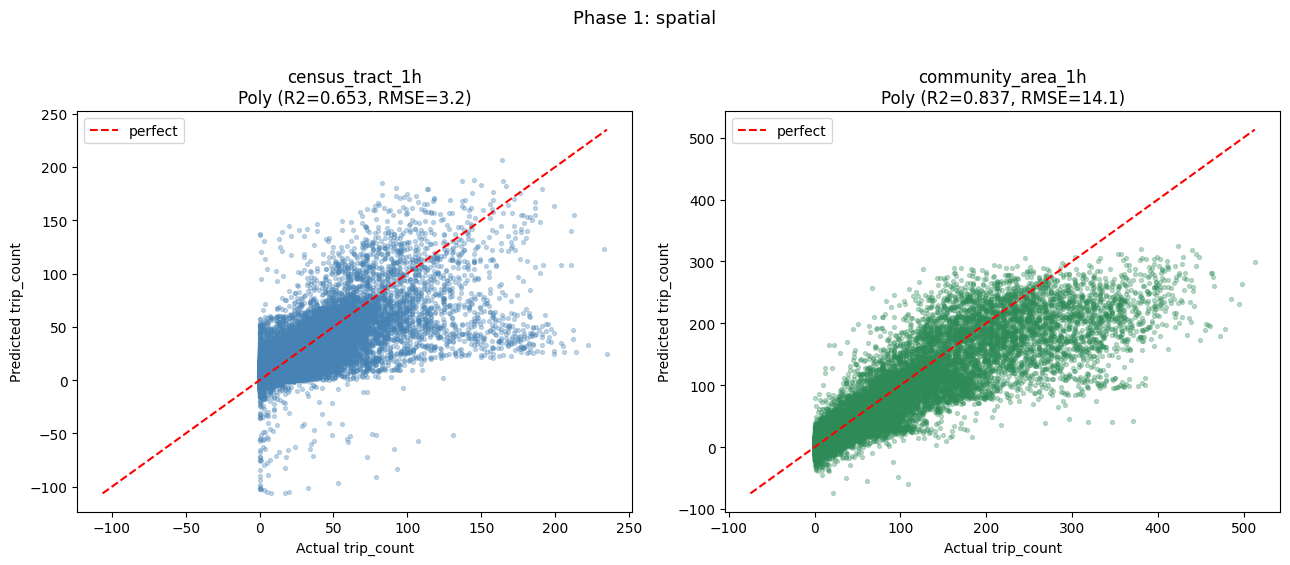

In [16]:
title, d = "Phase 1: spatial", phase1
n = len(d)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
for ax, (k, res) in zip(axes[0], d.items()):
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
    ax.legend()
fig.suptitle(title, y=1.02, fontsize=13)
plt.tight_layout();
plt.show()


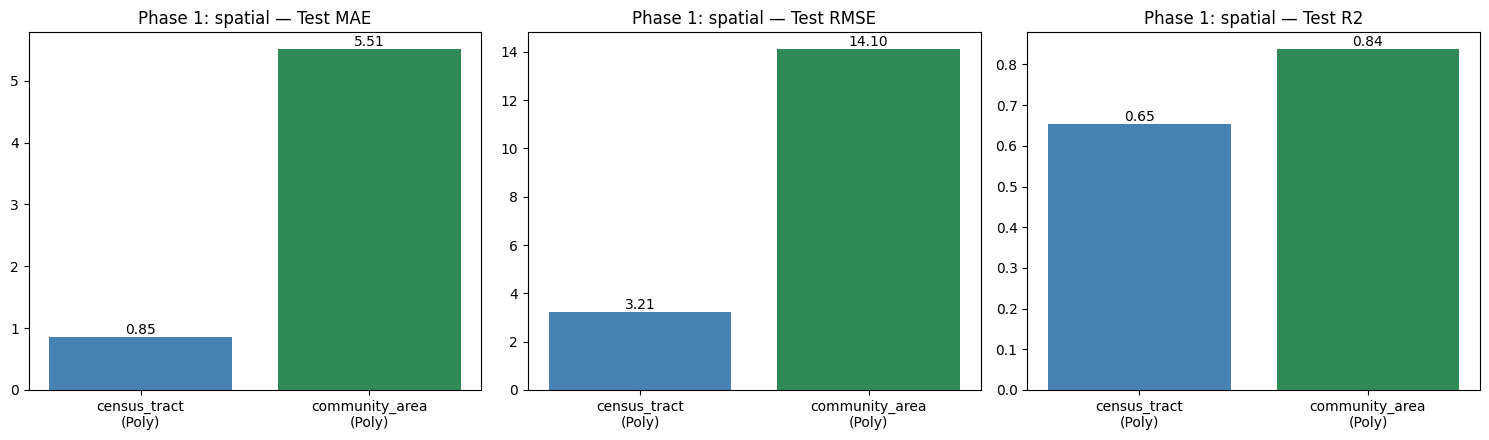

In [17]:
def metric_bars(results_dict, title, colors):
    metrics = ["test_mae", "test_rmse", "test_r2"]
    labels  = ["MAE", "RMSE", "R2"]
    names = list(results_dict.keys())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, m, lab in zip(axes, metrics, labels):
        vals = [results_dict[n][m] for n in names]
        labels = [f"{k}\n({v['best_model']})" for k, v in results_dict.items()]
        bars = ax.bar(labels, vals, color=[colors.get(n, "steelblue") for n in names])
        ax.set_title(f"{title} — Test {lab}")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:.2f}", ha="center", va="bottom")
    plt.tight_layout(); plt.show()

metric_bars(phase1, "Phase 1: spatial",
            {k: SPATIAL_COLORS[v["spatial"]] for k, v in phase1.items()})


# 6) Phase 2 — Target encoding comparison (1 h)
Target encoding gives the model each location's average demand level (computed on training data only). We compare all four combinations of spatial layer × encoding to show how strongly each layer depends on it.


In [18]:
phase_te = {
    "census_tract + TE":      grid_results["census_tract_1h"],
    "census_tract (no TE)":   grid_results["census_tract_1h (no TE)"],
    "community_area + TE":    grid_results["community_area_1h"],
    "community_area (no TE)": grid_results["community_area_1h (no TE)"],
}
for k, r in phase_te.items():
    print(f"{k:28s} R2={r['test_r2']:.4f}  MAPE={r['test_mape']:.1f}%")


census_tract + TE            R2=0.6535  MAPE=93.5%
census_tract (no TE)         R2=0.2383  MAPE=87.3%
community_area + TE          R2=0.8372  MAPE=182.4%
community_area (no TE)       R2=0.8330  MAPE=204.2%


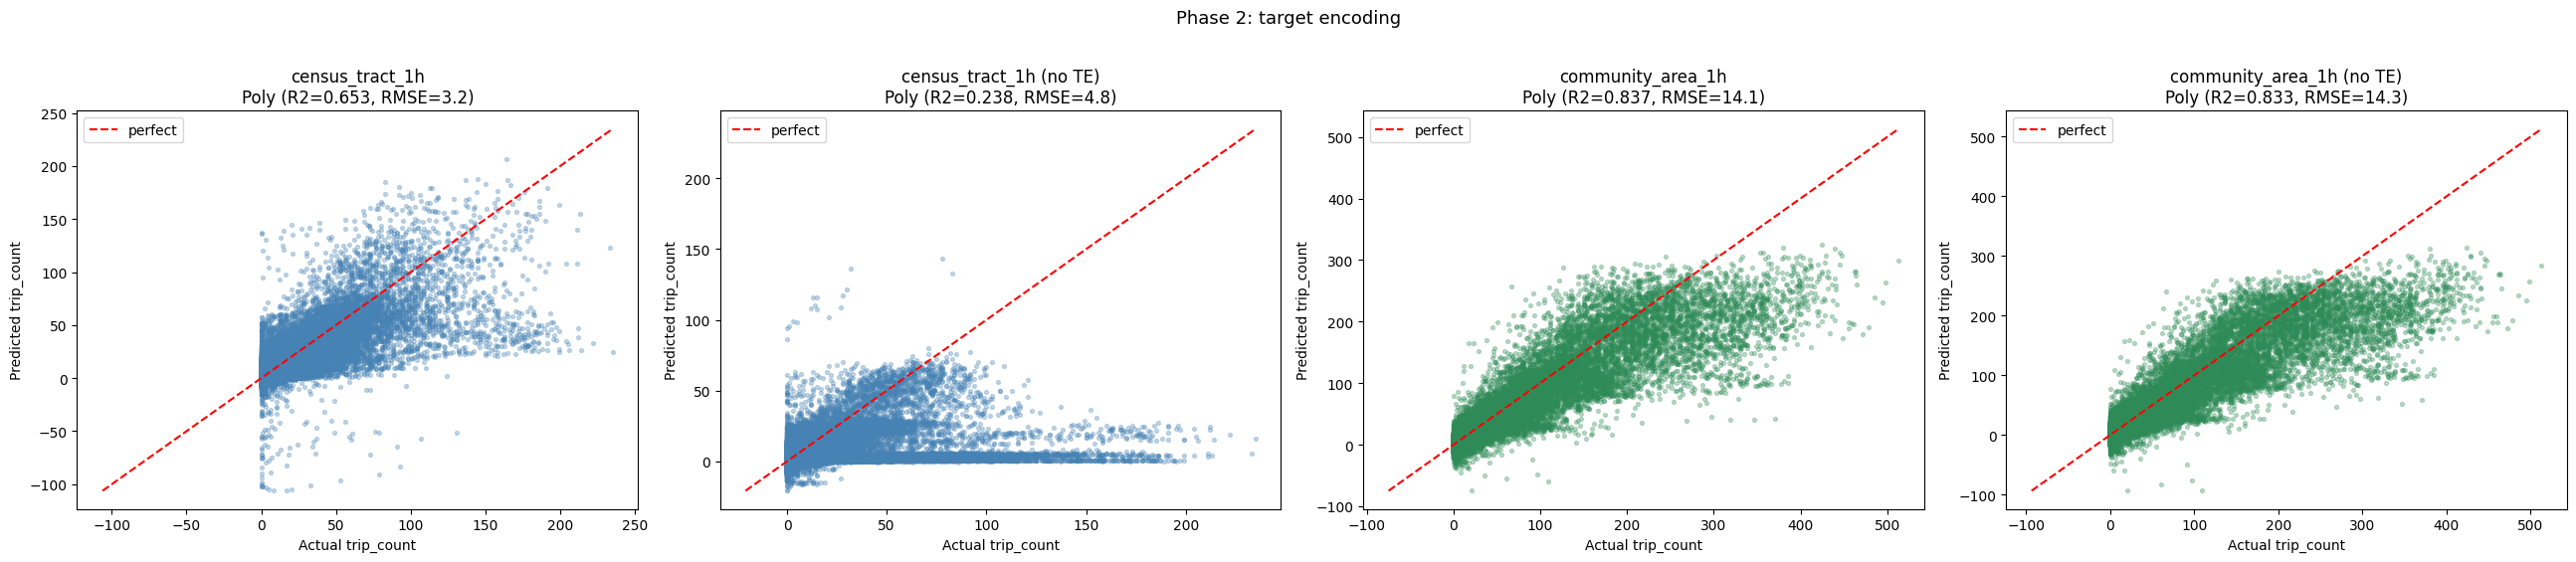

In [19]:
title, d = "Phase 2: target encoding", phase_te
n = len(d)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
for ax, (k, res) in zip(axes[0], d.items()):
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
    ax.legend()
fig.suptitle(title, y=1.02, fontsize=13)
plt.tight_layout();
plt.show()


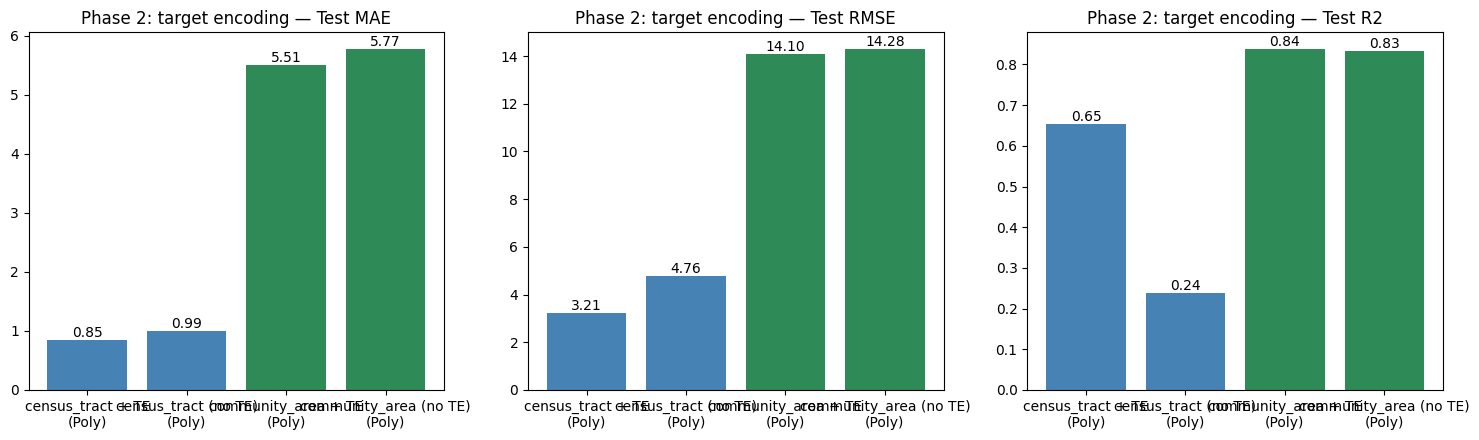

In [20]:
metric_bars(phase_te, "Phase 2: target encoding",
            {k: SPATIAL_COLORS[v["spatial"]] for k, v in phase_te.items()})


# 7) Phase 3 — Target transform comparison (1 h)
Using the best spatial layer from Phase 1, a **normal** vs **`log1p`** target is compared at 1 h. Both results are looked up from `grid_results`. The `log1p` transform compresses the right-skewed demand distribution; predictions are mapped back with `expm1` and all metrics are computed against the original-scale test target.


In [21]:
phase2 = {"normal": grid_results[f"{BEST_SPATIAL}_1h"],
          "log1p":  grid_results[f"{BEST_SPATIAL}_1h + log1p"]}
if phase2["log1p"]["test_r2"] > phase2["normal"]["test_r2"]:
    BEST_TARGET = "log1p"
else:
    BEST_TARGET = "normal"
print(f">> Best target setting (1h): {BEST_TARGET} (R2={phase2[BEST_TARGET]['test_r2']:.4f})")


>> Best target setting (1h): normal (R2=0.8372)


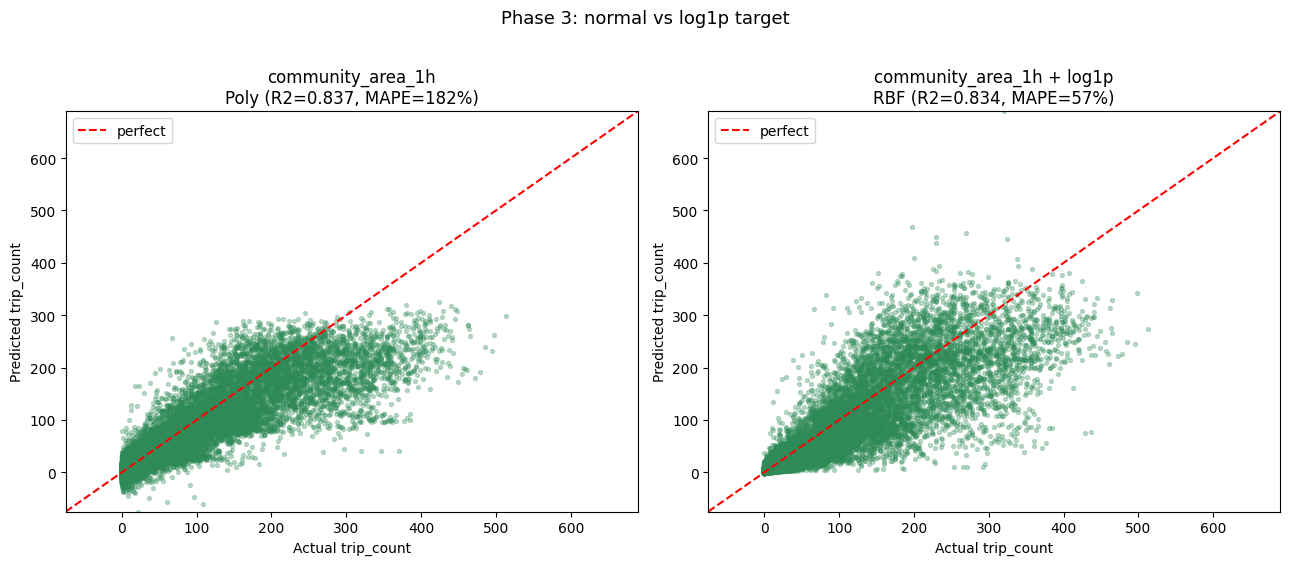

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
all_vals = np.concatenate([phase2["normal"]["y_test"], phase2["normal"]["y_pred"],
                           phase2["log1p"]["y_test"],  phase2["log1p"]["y_pred"]])
lims = [all_vals.min(), all_vals.max()]
for ax, key in zip(axes, ["normal", "log1p"]):
    res = phase2[key]
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f"{res['tag']}\n{res['best_model']} "
                 f"(R2={res['test_r2']:.3f}, MAPE={res['test_mape']:.0f}%)")
    ax.legend()
fig.suptitle("Phase 3: normal vs log1p target", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


# 8) Phase 4 — Temporal resolution comparison
With the best spatial layer and best target setting fixed, the three temporal resolutions (**1 h, 4 h, 1 d**) are compared. All three results are looked up from `grid_results`.

Coarser temporal bins aggregate more trips per basket, so absolute demand (and RMSE) increase — the relevant comparison is **R²** (relative fit quality) and **MAPE** (relative error).


In [23]:
suffix = " + log1p" if BEST_TARGET == "log1p" else ""
phase3 = {"1h": grid_results[f"{BEST_SPATIAL}_1h{suffix}"],
          "4h": grid_results[f"{BEST_SPATIAL}_4h{suffix}"],
          "1d": grid_results[f"{BEST_SPATIAL}_1d{suffix}"]}


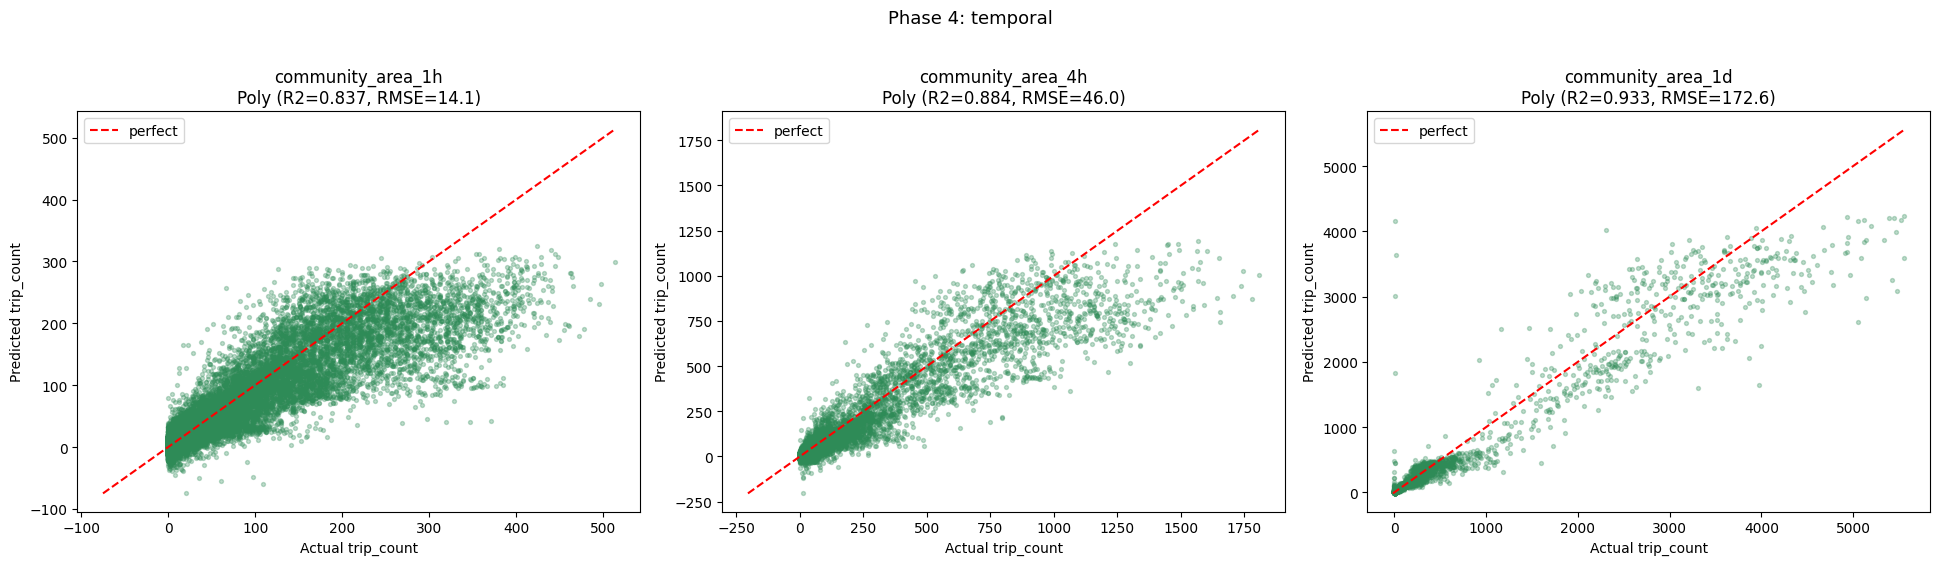

In [24]:
title, d = "Phase 4: temporal", phase3
n = len(d)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
for ax, (k, res) in zip(axes[0], d.items()):
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
    ax.legend()
fig.suptitle(title, y=1.02, fontsize=13)
plt.tight_layout();
plt.show()


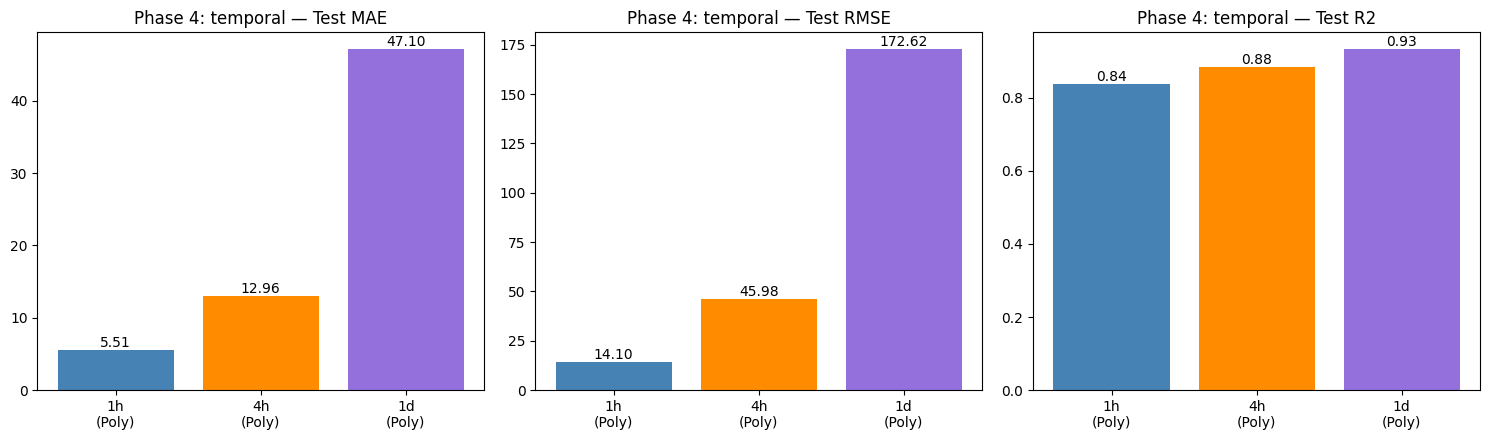

In [25]:
metric_bars(phase3, "Phase 4: temporal", BIN_COLORS)


# 9) Results — consolidated comparison
The table below collects every approach evaluated across the three phases. Each row is one full pipeline run (LinearSVR → RBF → Poly tuned on the validation set; best family refit and scored on the test set).


In [42]:
#| label: tbl-svr-phases
#| tbl-cap: "SVR results across four controlled comparison phases."
def _row(res, phase):
    return {
        "Phase": phase,
        "Configuration": res["tag"],
        "Spatial": res["spatial"],
        "Bin": res["bin"],
        "Target": "log1p" if res["log_target"] else "normal",
        "Target Enc.": "yes" if res.get("target_encoding", True) else "no",
        "Best kernel": res["best_model"],
        "Val RMSE": round(res["val_rmse"], 4),
        "Test MAE": round(res["test_mae"], 4),
        "Test RMSE": round(res["test_rmse"], 4),
        "Test R2": round(res["test_r2"], 4),
        "Test MAPE": round(res["test_mape"], 2),
    }

rows = [_row(phase1["census_tract"], "1: spatial"),
        _row(phase1["community_area"], "1: spatial"),
        _row(phase2["normal"], "2: target"),
        _row(phase2["log1p"],  "2: target")]
rows += [_row(phase3[b], "3: temporal") for b in ["1h", "4h", "1d"]]

display(pl.DataFrame(rows))
print(f"\nSelected: spatial={BEST_SPATIAL} | target={BEST_TARGET}")


Phase,Configuration,Spatial,Bin,Target,Target Enc.,Best kernel,Val RMSE,Test MAE,Test RMSE,Test R2,Test MAPE
str,str,str,str,str,str,str,f64,f64,f64,f64,f64
"""1: spatial""","""census_tract_1h""","""census_tract""","""1h""","""normal""","""yes""","""Poly""",3.3226,0.8541,3.2138,0.6535,93.46
"""1: spatial""","""community_area_1h""","""community_area""","""1h""","""normal""","""yes""","""Poly""",15.5955,5.5083,14.1005,0.8372,182.41
"""2: target""","""community_area_1h""","""community_area""","""1h""","""normal""","""yes""","""Poly""",15.5955,5.5083,14.1005,0.8372,182.41
"""2: target""","""community_area_1h + log1p""","""community_area""","""1h""","""log1p""","""yes""","""RBF""",16.2376,3.3335,14.2397,0.8339,57.06
"""3: temporal""","""community_area_1h""","""community_area""","""1h""","""normal""","""yes""","""Poly""",15.5955,5.5083,14.1005,0.8372,182.41
"""3: temporal""","""community_area_4h""","""community_area""","""4h""","""normal""","""yes""","""Poly""",51.8115,12.9631,45.9765,0.8842,170.32
"""3: temporal""","""community_area_1d""","""community_area""","""1d""","""normal""","""yes""","""Poly""",205.4948,47.1012,172.6224,0.9328,121.78



Selected: spatial=community_area | target=normal


In [27]:
# census_tract_1d + log1p shows R² = -53.5 because the polynomial kernel extrapolates explosively after back-transformation from log scale.The custom original-scale scorer ensures RBF is selected wherever this matters.
grid_rows = [_row(r, "full grid") for r in grid_results.values()]
display(pl.DataFrame(grid_rows).sort("Test R2", descending=True))
best_tag = max(grid_results, key=lambda k: grid_results[k]["test_r2"])
b = grid_results[best_tag]
print(f"\n>> Best SVR overall: {best_tag} | kernel={b['best_model']} | "
      f"R2={b['test_r2']:.4f} MAPE={b['test_mape']:.2f}%")


Phase,Configuration,Spatial,Bin,Target,Target Enc.,Best kernel,Val RMSE,Test MAE,Test RMSE,Test R2,Test MAPE
str,str,str,str,str,str,str,f64,f64,f64,f64,f64
"""full grid""","""community_area_1d""","""community_area""","""1d""","""normal""","""yes""","""Poly""",205.4948,47.1012,172.6224,0.9328,121.78
"""full grid""","""community_area_1d (no TE)""","""community_area""","""1d""","""normal""","""no""","""Poly""",229.8037,50.1614,172.9464,0.9326,157.61
"""full grid""","""community_area_1d + log1p (no …","""community_area""","""1d""","""log1p""","""no""","""Poly""",195.5397,49.2925,177.5017,0.929,110.98
"""full grid""","""community_area_4h + log1p""","""community_area""","""4h""","""log1p""","""yes""","""RBF""",48.1299,9.9503,41.2115,0.907,64.26
"""full grid""","""community_area_4h + log1p (no …","""community_area""","""4h""","""log1p""","""no""","""RBF""",48.5756,11.0406,45.9268,0.8845,68.14
…,…,…,…,…,…,…,…,…,…,…,…
"""full grid""","""census_tract_4h (no TE)""","""census_tract""","""4h""","""normal""","""no""","""Poly""",21.7474,5.6084,17.6083,0.2657,160.44
"""full grid""","""census_tract_4h + log1p (no TE…","""census_tract""","""4h""","""log1p""","""no""","""RBF""",22.2783,1.9969,17.8554,0.2449,86.63
"""full grid""","""census_tract_1h (no TE)""","""census_tract""","""1h""","""normal""","""no""","""Poly""",5.2762,0.9934,4.7648,0.2383,87.32



>> Best SVR overall: community_area_1d | kernel=Poly | R2=0.9328 MAPE=121.78%


## All metrics across configurations


In [28]:
# compute all relevant regression metrics from existing grid_results
# no retraining needed — y_test and y_pred are already stored
#
# R2      = coefficient of determination (1 = perfect, higher is better)
# MAE     = mean absolute error in trips (lower is better, scale-dependent)
# RMSE    = root mean squared error in trips (penalizes large errors more)
# MedAE   = median absolute error (robust to outliers)
# RMAE    = relative MAE = MAE / mean(y_test), comparable across scales
# RRMSE   = relative RMSE = RMSE / mean(y_test), comparable across scales
# MAPE%   = mean absolute percentage error (only on rows where y_test > 0)
metrics_rows = []
for tag, res in grid_results.items():
    yt = res["y_test"]
    yp = res["y_pred"]
    errors = np.abs(yt - yp)
    mask = yt > 0

    mae = np.mean(errors)
    rmse = np.sqrt(np.mean((yt - yp) ** 2))
    r2 = 1 - np.sum((yt - yp) ** 2) / np.sum((yt - np.mean(yt)) ** 2)

    metrics_rows.append({
        "Config": tag,
        "Kernel": res["best_model"],
        "Spatial": res["spatial"],
        "Bin": res["bin"],
        "Log": "yes" if res["log_target"] else "no",
        "TE": "yes" if res.get("target_encoding", True) else "no",
        "R2": round(r2, 4),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MedAE": round(float(np.median(errors)), 2),
        "RMAE": round(mae / np.mean(yt), 4),
        "RRMSE": round(rmse / np.mean(yt), 4),
        "MAPE%": round(float(np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100), 1),
    })

all_metrics = pl.DataFrame(metrics_rows)
display(all_metrics.sort("R2", descending=True))


Config,Kernel,Spatial,Bin,Log,TE,R2,MAE,RMSE,MedAE,RMAE,RRMSE,MAPE%
str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64
"""community_area_1d""","""Poly""","""community_area""","""1d""","""no""","""yes""",0.9328,47.1,172.62,9.78,0.2375,0.8705,121.8
"""community_area_1d (no TE)""","""Poly""","""community_area""","""1d""","""no""","""no""",0.9326,50.16,172.95,11.53,0.2529,0.8721,157.6
"""community_area_1d + log1p (no …","""Poly""","""community_area""","""1d""","""yes""","""no""",0.929,49.29,177.5,7.85,0.2486,0.8951,111.0
"""community_area_4h + log1p""","""RBF""","""community_area""","""4h""","""yes""","""yes""",0.907,9.95,41.21,1.48,0.2995,1.2403,64.3
"""community_area_4h + log1p (no …","""RBF""","""community_area""","""4h""","""yes""","""no""",0.8845,11.04,45.93,1.56,0.3323,1.3822,68.1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""census_tract_4h (no TE)""","""Poly""","""census_tract""","""4h""","""no""","""no""",0.2657,5.61,17.61,3.91,2.2651,7.1116,160.4
"""census_tract_4h + log1p (no TE…","""RBF""","""census_tract""","""4h""","""yes""","""no""",0.2449,2.0,17.86,0.05,0.8065,7.2114,86.6
"""census_tract_1h (no TE)""","""Poly""","""census_tract""","""1h""","""no""","""no""",0.2383,0.99,4.76,0.43,1.6036,7.6921,87.3


In [29]:
def accuracy_report(y_true, y_pred, abs_tolerances=(0, 1, 2, 5), rel_tolerances=(0.10, 0.20)):
    """'Correct prediction' rates under several tolerance definitions.

    - abs_tolerances[0] == 0  -> exact match on the rounded prediction
    - remaining abs_tolerances -> within +/- N trips of the actual count
    - rel_tolerances           -> within +/- X% of the actual count
                                  (rows with actual == 0 are excluded,
                                  same convention as MAPE)
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    abs_err = np.abs(np.round(y_pred) - y_true)

    report = {"n_test": len(y_true)}
    for tol in abs_tolerances:
        label = "exact_match" if tol == 0 else f"within_{tol}_trips"
        report[label] = float(np.mean(abs_err <= tol))

    nonzero = y_true != 0
    rel_err = np.abs(y_pred[nonzero] - y_true[nonzero]) / y_true[nonzero]
    for tol in rel_tolerances:
        report[f"within_{int(tol * 100)}pct"] = float(np.mean(rel_err <= tol))
    return report

accuracy_rows = []
for tag, res in grid_results.items():
    row = {"experiment": tag}
    row.update(accuracy_report(res["y_test"], res["y_pred"]))
    accuracy_rows.append(row)

accuracy_df = pl.DataFrame(accuracy_rows)
# show percentages rounded, sorted by the +/-5 trips hit rate
display(accuracy_df.with_columns([
    (pl.col(c) * 100).round(1)
    for c in accuracy_df.columns if c not in ("experiment", "n_test")
]).sort("within_5_trips", descending=True))


experiment,n_test,exact_match,within_1_trips,within_2_trips,within_5_trips,within_10pct,within_20pct
str,i64,f64,f64,f64,f64,f64,f64
"""census_tract_1h""",1449082,53.7,93.4,96.1,98.1,6.5,13.1
"""census_tract_1h + log1p (no TE…",1449082,52.8,93.7,97.1,98.1,5.0,10.3
"""census_tract_1h (no TE)""",1449082,56.2,92.4,96.2,98.0,3.9,8.2
"""census_tract_1h + log1p""",1449082,52.6,93.3,97.0,97.9,3.6,7.5
"""census_tract_4h""",362341,52.6,90.6,93.6,96.1,6.0,12.1
…,…,…,…,…,…,…,…
"""community_area_4h (no TE)""",58985,5.4,16.1,26.0,51.6,7.3,14.5
"""community_area_1d + log1p""",9840,4.9,14.2,22.3,42.2,16.8,32.6
"""community_area_1d + log1p (no …",9840,4.7,13.0,20.8,39.3,16.4,32.7


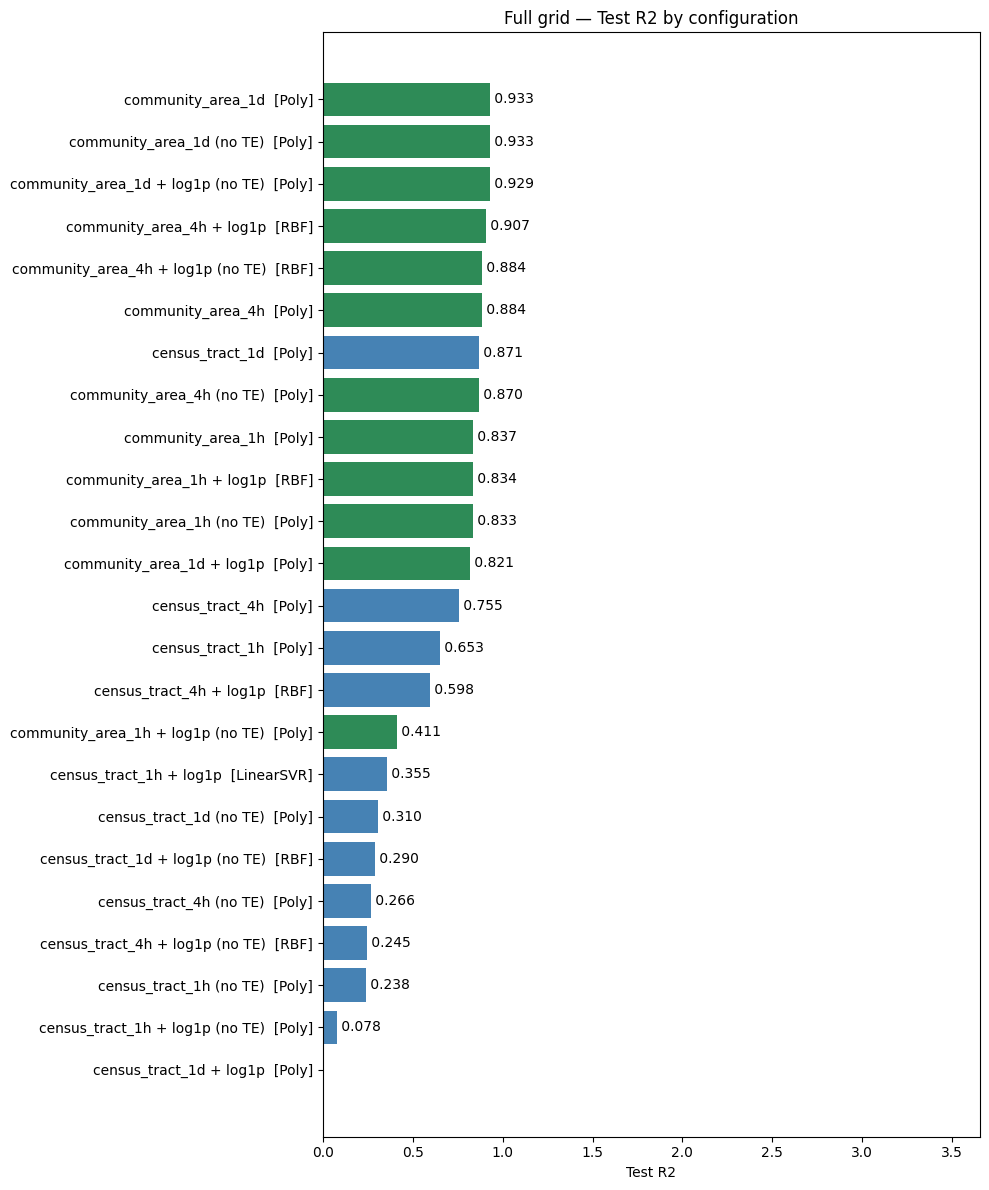

In [35]:
# all 24 configurations at a glance, sorted by test R2
sorted_tags = sorted(grid_results, key=lambda k: grid_results[k]["test_r2"])
bar_labels = [f"{t}  [{grid_results[t]['best_model']}]" for t in sorted_tags]
r2_vals = [grid_results[t]["test_r2"] for t in sorted_tags]
colors  = [SPATIAL_COLORS[grid_results[t]["spatial"]] for t in sorted_tags]

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(bar_labels, r2_vals, color=colors)

for bar, v in zip(bars, r2_vals):
    # Text nur schreiben, wenn der Wert >= 0 ist (oder zumindest nicht extrem negativ)
    if v >= -1: 
        ax.text(max(0, bar.get_width()), bar.get_y() + bar.get_height()/2,
                f" {v:.3f}", va="center")

ax.set_xlabel("Test R2")
ax.set_xlim(left=0) # Bild fängt bei 0 an
ax.set_title("Full grid — Test R2 by configuration")
plt.tight_layout()
plt.show()


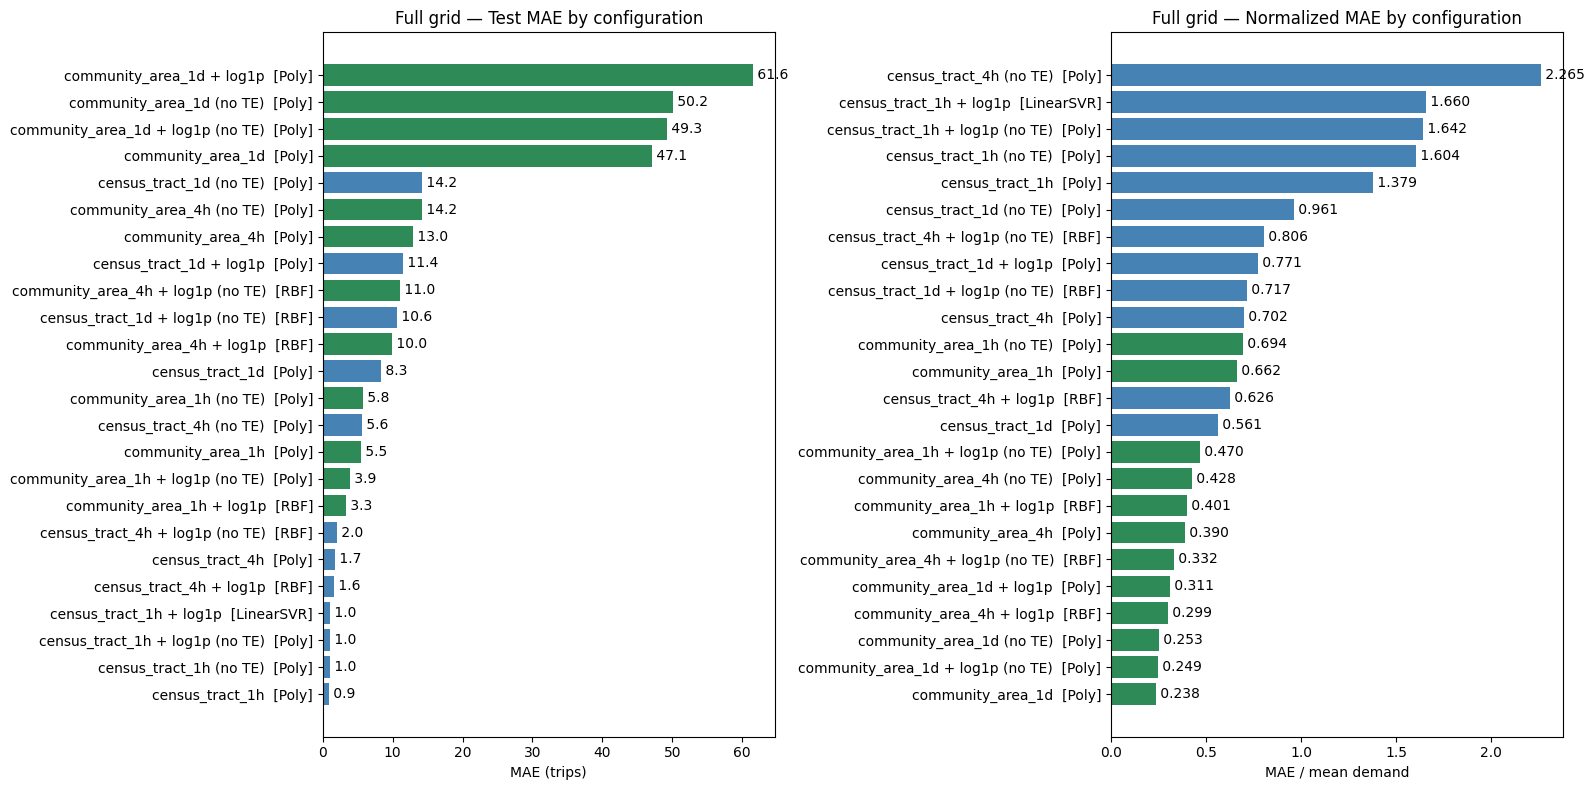

In [31]:
# raw MAE is scale-dependent (1d windows hold ~24x more trips than 1h),
# normalized MAE divides by each config's mean demand to compare across scales
tags_mae = sorted(grid_results, key=lambda k: grid_results[k]["test_mae"])
labels_mae = [f"{t}  [{grid_results[t]['best_model']}]" for t in tags_mae]
vals_mae = [grid_results[t]["test_mae"] for t in tags_mae]
colors_mae = [SPATIAL_COLORS[grid_results[t]["spatial"]] for t in tags_mae]

tags_nmae = sorted(grid_results, key=lambda k: grid_results[k]["test_mae"] / grid_results[k]["y_test"].mean())
labels_nmae = [f"{t}  [{grid_results[t]['best_model']}]" for t in tags_nmae]
vals_nmae = [grid_results[t]["test_mae"] / grid_results[t]["y_test"].mean() for t in tags_nmae]
colors_nmae = [SPATIAL_COLORS[grid_results[t]["spatial"]] for t in tags_nmae]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
bars = axes[0].barh(labels_mae, vals_mae, color=colors_mae)
for bar, v in zip(bars, vals_mae):
    axes[0].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f" {v:.1f}", va="center")
axes[0].set_xlabel("MAE (trips)")
axes[0].set_title("Full grid — Test MAE by configuration")
bars = axes[1].barh(labels_nmae, vals_nmae, color=colors_nmae)
for bar, v in zip(bars, vals_nmae):
    axes[1].text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f" {v:.3f}", va="center")
axes[1].set_xlabel("MAE / mean demand")
axes[1].set_title("Full grid — Normalized MAE by configuration")
plt.tight_layout(); plt.show()


# 10) Kernel comparison
Validation RMSE of the three kernel families shows how performance improves as the model becomes more complex (linear → RBF → polynomial).


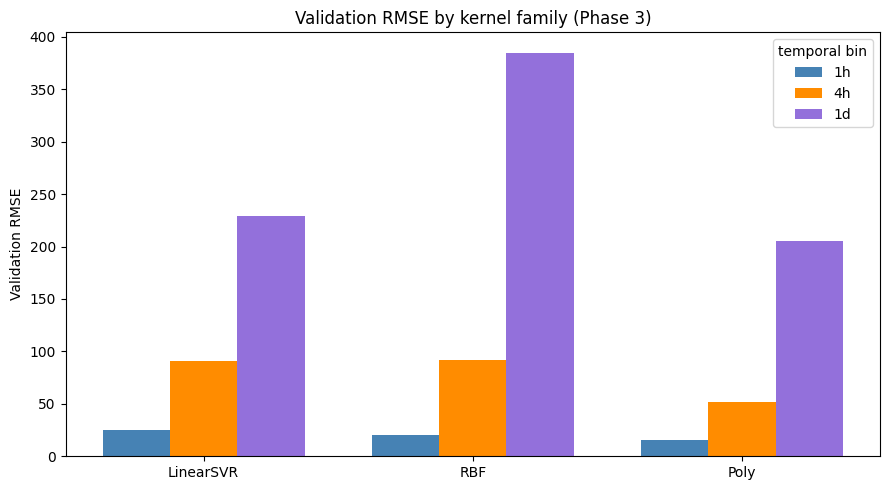

In [32]:
families = ["LinearSVR", "RBF", "Poly"]
x = np.arange(len(families))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, b in enumerate(["1h", "4h", "1d"]):
    vals = [phase3[b]["all_val_rmse"].get(f, np.nan) for f in families]
    ax.bar(x + i * width, vals, width, label=b, color=BIN_COLORS[b])
ax.set_xticks(x + width); ax.set_xticklabels(families)
ax.set_ylabel("Validation RMSE"); ax.set_title("Validation RMSE by kernel family (Phase 3)")
ax.legend(title="temporal bin")
plt.tight_layout(); plt.show()


# 11) Shortfalls & improvement levers

**Model performance & shortfalls**
- *Right-skewed target*: `trip_count` has a long right tail, so the squared-error objective is dominated by a few high-demand baskets. The `log1p` transform (Phase 2) helps stabilise the variance but can reduce R² on the original scale because it under-predicts extreme peaks.
- *Sparse spatial units*: many census tracts contain only a handful of trips per basket, making per-unit predictions noisy — this is why the coarser **community area** layer generally fits better (more trips per unit, less noise).
- *Resolution trade-off*: finer temporal bins (1 h) give more detail but also more noise and sparser baskets; coarser bins (4 h, 1 d) aggregate demand and are easier to predict (higher R², lower MAPE) but lose intra-day structure.
- *SVR scaling limitation*: kernel SVR (RBF/Poly) scales ~O(n²), so grid search fits on a 20 k-row subsample and the final refit on 50 k rows — the full training set (300 k–600 k rows) is intractable for non-linear SVR.
- *No temporal dynamics*: the model receives no information about *recent* demand (no autoregressive lags), only calendar/weather/POI context.

**How performance varies with resolution**
- Increasing **spatial** resolution (community area → census tract) adds more, sparser units: MAE falls but R² drops and MAPE rises because small counts are harder to predict *relatively*.
- Increasing **temporal** resolution (1 d → 4 h → 1 h) adds noise: daily baskets are easiest to predict (highest R²), hourly the hardest.

**Improvement levers for a follow-up project**
- *Lagged / autoregressive features*: `trip_count` at t-1, t-24h and rolling means — the strongest short-term predictor.
- *Spatial features*: POI density, distance to CBD / nearest transit hub, neighbourhood embeddings.
- *Stronger learners*: gradient-boosted trees (LightGBM / XGBoost) handle non-linearities, large *n* and feature interactions far more efficiently than kernel SVR.
- *Spatial / grouped cross-validation*: group folds by spatial unit and time block so nearby/overlapping observations do not leak between folds.
- *Calibrated probabilistic forecasts*: predict demand distributions (quantiles) rather than point estimates.


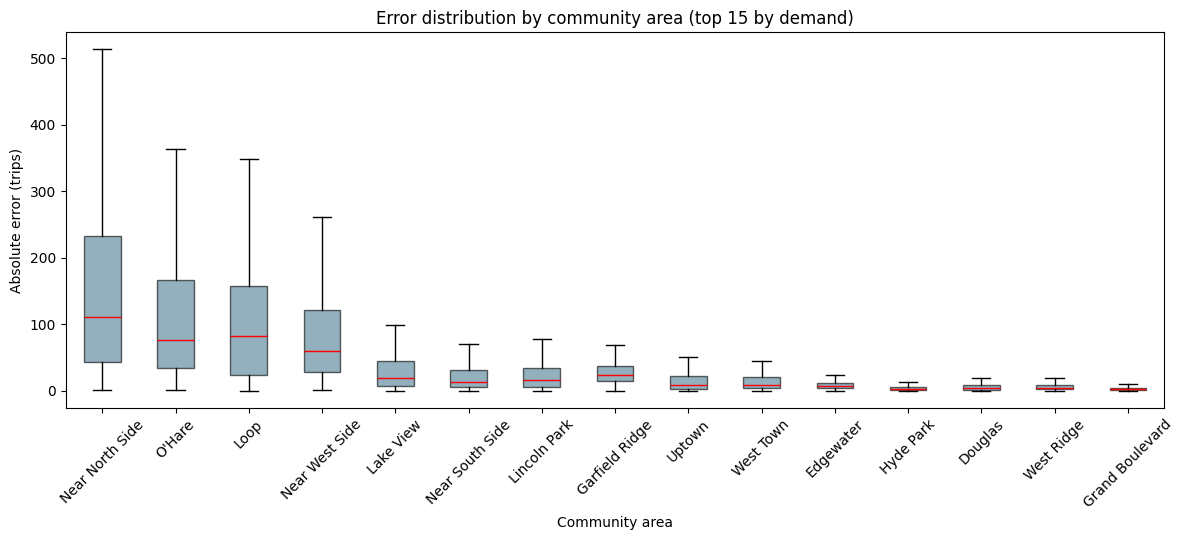

In [41]:
#| label: fig-svr-error-boxplot
#| fig-cap: "Absolute error distribution by community area (top 15 by demand) for the recommended configuration (community area, 4h, log1p, RBF)."

CA_NAMES = {
    8: "Near North Side", 76: "O'Hare", 32: "Loop",
    28: "Near West Side", 6: "Lake View", 33: "Near South Side",
    7: "Lincoln Park", 56: "Garfield Ridge", 3: "Uptown",
    24: "West Town", 77: "Edgewater", 41: "Hyde Park",
    35: "Douglas", 2: "West Ridge", 38: "Grand Boulevard"
}

res = grid_results["community_area_4h + log1p"]
pred_ca = ca_4h_test.select(["community_area"]).with_columns([
    pl.Series("actual", res["y_test"]),
    pl.Series("predicted", res["y_pred"]),
    pl.Series("abs_error", np.abs(res["y_test"] - res["y_pred"])),
])

top_cas = (pred_ca.group_by("community_area")
           .agg(pl.col("actual").mean())
           .sort("actual", descending=True)
           .head(15)["community_area"].to_list())

top_labels = [CA_NAMES.get(ca, str(ca)) for ca in top_cas]

groups = [pred_ca.filter(pl.col("community_area") == ca)["abs_error"].to_numpy()
          for ca in top_cas]

fig, ax = plt.subplots(figsize=(12, 5.5))
bp = ax.boxplot(groups, tick_labels=top_labels, patch_artist=True,
                boxprops=dict(facecolor="#4a7c91", alpha=0.6),
                medianprops=dict(color="red"), showfliers=False)
ax.set_xlabel("Community area")
ax.set_ylabel("Absolute error (trips)")
ax.set_title("Error distribution by community area (top 15 by demand)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## Example predictions by spatial unit


In [37]:
# attach predictions of the recommended config back to their spatial units
res = grid_results["community_area_4h + log1p"]
assert len(ca_4h_test) == len(res["y_test"])
pred_table = ca_4h_test.select(["community_area"]).with_columns([
    pl.Series("actual", res["y_test"]),
    pl.Series("predicted", res["y_pred"].round(1)),
])
print("Sample rows:")
display(pred_table.head(5))
print("Top 10 spatial units by predicted demand:")
display(pred_table.group_by("community_area")
        .agg(pl.col("predicted").mean().round(1))
        .sort("predicted", descending=True).head(10))

Sample rows:


community_area,actual,predicted
i64,f64,f64
75,3.0,5.1
76,144.0,159.6
77,41.0,36.5
1,22.0,15.7
2,28.0,27.1


Top 10 spatial units by predicted demand:


community_area,predicted
i64,f64
76,522.0
8,506.8
32,386.3
28,259.6
6,75.7
56,72.3
33,68.2
7,48.1
3,39.4
